# Data Cleaning Pipeline
This notebook performs data cleaning for the NYC real estate dataset.

## Steps
1. Load data
2. Inspect dataset
3. Handle duplicates
4. Handle missing values
5. Validate data types
6. Detect outliers
7. Create analysis features (EDA only)
8. Export cleaned dataset

> **Note:** Features derived from `listing_price` (e.g. `price_per_sqft`, `price_vs_zestimate`) should not be used for model training because they introduce target leakage.


In [1]:
import pandas as pd
import numpy as np

In [2]:
df= pd.read_csv("/content/final_df.csv")

In [3]:
df.sample(10)

,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,home_type,days_on_zillow,listing_status,zpid,tax_assessed_value,clean_address
385,"2426 Brigham St, Brooklyn, NY 11235",11235,5.0,3.0,2265.0,40.593845,-73.934166,"$1,139,000",2922.0,1091300.0,MULTI_FAMILY,54,forSale,30748494,1025000.0,2426 BRIGHAM ST BROOKLYN NY 11235
601,"10120 Avenue, Brooklyn, NY 11236",11236,5.0,3.0,2120.0,NaN,NaN,"$995,000",3274.0,989300.0,MULTI_FAMILY,36,forSale,442155683,NaN,10120 AVENUE BROOKLYN NY 11236
1184,"16327 95th St, Howard Beach, NY 11414",11414,5.0,6.0,3400.0,40.652283,-73.836200,"$1,999,999",6493.0,1916400.0,SINGLE_FAMILY,24,forSale,32217843,1128000.0,16327 95TH ST HOWARD BEACH NY 11414
1745,"18103 145th Road, Springfield Gardens, NY 11413",11413,4.0,2.0,1336.0,40.664800,-73.764150,"$879,999",NaN,NaN,SINGLE_FAMILY,29,forSale,32207498,717000.0,18103 145TH ROAD SPRINGFIELD GARDENS NY 11413
1593,"16 W 14th Rd, Broad Channel, NY 11693",11693,3.0,1.0,747.0,40.603030,-73.820950,$0,3049.0,496500.0,SINGLE_FAMILY,527,forSale,32218986,391000.0,16 W 14TH RD BROAD CHANNEL NY 11693
1160,"10205 Davenport Court, Howard Beach, NY 11414",11414,6.0,4.0,2380.0,40.653385,-73.830320,"$949,000",NaN,NaN,MULTI_FAMILY,64,forSale,2056782526,NaN,10205 DAVENPORT COURT HOWARD BEACH NY 11414
4,"2711 Avenue X Unit F2, Brooklyn, NY 11235",11235,2.0,1.0,1000.0,40.704254,-73.966420,"$345,000",3056.0,350500.0,CONDO,20,forSale,463826019,NaN,2711 AVENUE X UNIT F2 BROOKLYN NY 11235
1286,"32-34 147th Place, Flushing, NY 11354",11354,3.0,2.0,1056.0,40.768980,-73.819466,"$1,150,000",NaN,NaN,SINGLE_FAMILY,75,forSale,32033410,1110000.0,3234 147TH PLACE FLUSHING NY 11354
1522,"85-10 151st Ave APT 5G, Howard Beach, NY 11414",11414,2.0,2.0,950.0,40.667995,-73.849340,"$325,000",2954.0,322900.0,CONDO,211,forSale,452807970,NaN,8510 151ST AVE APT 5G HOWARD BEACH NY 11414
1246,"25216 63 Avenue #4-1340, Little Neck, NY 11362",11362,3.0,1.0,960.0,40.756203,-73.725510,"$340,000",NaN,NaN,CONDO,92,forSale,462098972,NaN,25216 63 AVENUE 1340 LITTLE NECK NY 11362


In [4]:
df.shape

(2000, 16)

In [5]:


# -----------------------------
# Currency Columns
# -----------------------------
currency_cols = [
    "price",
    "zestimate",
    "rentZestimate",
    "taxAssessedValue"
]

for col in currency_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace(r'[$,]', '', regex=True)
            .replace(['nan', 'None', ''], np.nan)
        )
        df[col] = pd.to_numeric(df[col], errors="coerce")


# -----------------------------
# Numeric Columns
# -----------------------------
numeric_cols = [
    "bedrooms",
    "bathrooms",
    "livingArea",
    "lotArea/value",
    "daysOnZillow"
]

for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# -----------------------------
# Float Columns
# -----------------------------
float_cols = [
    "coordinates/latitude",
    "coordinates/longitude"
]

for col in float_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


# -----------------------------
# ZIP Code
# -----------------------------
if "addressZipcode" in df.columns:
    df["addressZipcode"] = (
        df["addressZipcode"]
        .astype(str)
        .str.extract(r'(\d{5})')[0]
    )


# -----------------------------
# Date Columns (if available)
# -----------------------------
date_cols = [
    "datePosted",
    "datePriceChanged"
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")


# -----------------------------
# Check Data Types
# -----------------------------
print(df.dtypes)

address                object
zip_code                int64
bedrooms              float64
bathrooms             float64
living_area           float64
latitude              float64
longitude             float64
listing_price          object
rent_estimate         float64
zestimate             float64
home_type              object
days_on_zillow          int64
listing_status         object
zpid                    int64
tax_assessed_value    float64
clean_address          object
dtype: object


In [6]:
print(df.info())

print(df[[
    "listing_price",
    "zestimate",
    "rent_estimate",
    "tax_assessed_value",
    "bedrooms",
    "bathrooms",
    "living_area",
    "latitude",
    "longitude",
    "zip_code"
]].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   address             2000 non-null   object 
 1   zip_code            2000 non-null   int64  
 2   bedrooms            1893 non-null   float64
 3   bathrooms           1936 non-null   float64
 4   living_area         1778 non-null   float64
 5   latitude            1979 non-null   float64
 6   longitude           1979 non-null   float64
 7   listing_price       2000 non-null   object 
 8   rent_estimate       1311 non-null   float64
 9   zestimate           1055 non-null   float64
 10  home_type           2000 non-null   object 
 11  days_on_zillow      2000 non-null   int64  
 12  listing_status      2000 non-null   object 
 13  zpid                2000 non-null   int64  
 14  tax_assessed_value  1266 non-null   float64
 15  clean_address       2000 non-null   object 
dtypes: flo

In [7]:
import numpy as np

def clean_and_convert_price(price_str):
    if pd.isna(price_str):
        return np.nan
    s = str(price_str).strip()
    # Handle currency symbols and commas first
    s = s.replace('$', '').replace(',', '')

    if 'K' in s.upper():
        s = s.upper().replace('K', '')
        try:
            return float(s) * 1000
        except ValueError:
            return np.nan
    elif 'M' in s.upper():
        s = s.upper().replace('M', '')
        try:
            return float(s) * 1000000
        except ValueError:
            return np.nan
    else:
        try:
            return float(s)
        except ValueError:
            return np.nan

df["listing_price"] = df["listing_price"].apply(clean_and_convert_price)

In [8]:
currency_cols = [
    "listing_price",
    "zestimate",
    "rent_estimate",
    "tax_assessed_value"
]

for col in currency_cols:
    if col in df.columns:
        df[col] = df[col].apply(clean_and_convert_price)

In [9]:
df["zip_code"] = df["zip_code"].astype(str)

* Bedrooms       ~5%  Median imputatio
* Bathrooms      ~2%. Median imputation
* Living Area    ~10% Median imputation
* Longitude/latitude  Drop missing rows
* Rent Estimate  ~34% keep missing rows
* Zestimate      ~47% keep missing rows
* Tax Value      ~37% keep missing rows

In [10]:
print(df.duplicated(subset="zpid").sum())

0


In [11]:
df["bedrooms"] = df["bedrooms"].fillna(df["bedrooms"].median())

In [12]:
df["bathrooms"] = df["bathrooms"].fillna(df["bathrooms"].median())

In [13]:
df["living_area"] = df["living_area"].fillna(df["living_area"].median())

In [14]:
df = df.dropna(subset=["latitude", "longitude"])

In [15]:
df.describe()

,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,days_on_zillow,zpid,tax_assessed_value
count,1979.000000,1979.000000,1979.000000,1979.000000,1979.000000,1.954000e+03,1302.000000,1.049000e+03,1979.000000,1.979000e+03,1.266000e+03
mean,3.563416,2.523497,1741.020212,40.654931,-73.862457,1.002103e+06,3802.138249,1.037533e+06,99.719555,3.148670e+08,4.553680e+06
std,2.298810,1.794224,1328.183829,0.058619,0.080487,1.235825e+06,1273.966004,1.095261e+06,139.314607,5.528455e+08,3.318256e+07
min,0.000000,0.000000,0.000000,40.556900,-74.035660,0.000000e+00,1280.000000,1.401000e+05,0.000000,3.056620e+07,2.200000e+03
25%,2.000000,2.000000,1048.500000,40.608431,-73.925697,5.211750e+05,3063.250000,6.524000e+05,18.000000,3.078700e+07,6.602500e+05
50%,3.000000,2.000000,1467.000000,40.643887,-73.892586,8.490000e+05,3551.500000,8.576000e+05,58.000000,3.222326e+07,8.170000e+05
75%,5.000000,3.000000,2079.500000,40.677368,-73.796070,1.177250e+06,4199.750000,1.186400e+06,122.000000,4.565372e+08,1.080750e+06
max,48.000000,48.000000,25000.000000,40.799720,-73.700676,2.500000e+07,23710.000000,1.765220e+07,1997.000000,2.146840e+09,4.007820e+08


In [16]:
df[df["bedrooms"] > 10][
    ["address", "home_type", "bedrooms", "listing_price"]
].sort_values("bedrooms", ascending=False)

,address,home_type,bedrooms,listing_price
1487,"223 Beach 101st St Unit 3C, Rockaway Park, NY ...",SINGLE_FAMILY,48.0,7750000.0
660,"768 Linden Blvd, Brooklyn, NY 11203",SINGLE_FAMILY,20.0,2350000.0
1832,"3448 10th St, Astoria, NY 11106",MULTI_FAMILY,18.0,3950000.0
1830,"34-46 10th Street, Astoria, NY 11106",MULTI_FAMILY,18.0,3950000.0
19,"299 Troutman St, Brooklyn, NY 11237",MULTI_FAMILY,16.0,500000.0
87,"299 Troutman St #1, Brooklyn, NY 11237",SINGLE_FAMILY,16.0,500000.0
929,"1646 Benson Ave, Brooklyn, NY 11214",MULTI_FAMILY,14.0,1287000.0
428,"448 E 48th St #6FAM, Brooklyn, NY 11203",SINGLE_FAMILY,12.0,950000.0
84,"27 Sherlock Pl, Brooklyn, NY 11233",MULTI_FAMILY,12.0,750000.0
108,"1434 Greene Ave #1-6, Brooklyn, NY 11237",SINGLE_FAMILY,12.0,899975.0


In [17]:
df[df["bathrooms"] > 10][
    ["address", "home_type", "bathrooms", "listing_price"]
]

,address,home_type,bathrooms,listing_price
660,"768 Linden Blvd, Brooklyn, NY 11203",SINGLE_FAMILY,16.0,2350000.0
709,"636 E 96th St #6UNITS, Brooklyn, NY 11236",SINGLE_FAMILY,12.0,1695000.0
740,"725 E 48th St, Brooklyn, NY 11203",SINGLE_FAMILY,12.0,849999.0
1487,"223 Beach 101st St Unit 3C, Rockaway Park, NY ...",SINGLE_FAMILY,48.0,7750000.0
1830,"34-46 10th Street, Astoria, NY 11106",MULTI_FAMILY,15.0,3950000.0
1832,"3448 10th St, Astoria, NY 11106",MULTI_FAMILY,15.0,3950000.0


In [18]:
df[df["living_area"] == 0]

,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,home_type,days_on_zillow,listing_status,zpid,tax_assessed_value,clean_address
145,"1748 E 55th St #42C, Brooklyn, NY 11234",11234,2.0,1.0,0.0,40.614567,-73.921740,330000.0,2936.0,319800.0,CONDO,2,forSale,2071477259,NaN,1748 E 55TH ST BROOKLYN NY 11234
158,"142 East 88 Street, Brooklyn, NY 11236",11236,4.0,2.0,0.0,40.649254,-73.918940,615000.0,5400.0,645500.0,SINGLE_FAMILY,281,forSale,30655182,728000.0,142 EAST 88 STREET BROOKLYN NY 11236
397,"2048 E 58th St, Brooklyn, NY 11234",11234,2.0,1.0,0.0,40.614147,-73.917730,325000.0,2466.0,317700.0,CONDO,177,forSale,460244450,NaN,2048 E 58TH ST BROOKLYN NY 11234
417,"9208 Avenue N #201, Brooklyn, NY 11236",11236,1.0,2.0,0.0,40.633026,-73.895004,395000.0,3235.0,388900.0,CONDO,39,forSale,463413939,NaN,9208 AVENUE N BROOKLYN NY 11236
521,"9014 Avenue A, Brooklyn, NY 11236",11236,3.0,2.0,0.0,40.651290,-73.917530,725000.0,3990.0,704100.0,SINGLE_FAMILY,146,forSale,30655319,718000.0,9014 AVENUE A BROOKLYN NY 11236
526,"8617 Avenue J, Brooklyn, NY 11236",11236,4.0,2.0,0.0,40.637188,-73.906740,669000.0,3630.0,674300.0,SINGLE_FAMILY,109,forSale,30769381,695000.0,8617 AVENUE J BROOKLYN NY 11236
533,"1001 E 108th St APT 1B, Brooklyn, NY 11236",11236,1.0,1.0,0.0,40.647210,-73.889910,229000.0,2797.0,NaN,CONDO,113,forSale,245003502,4110000.0,1001 E 108TH ST APT 1B BROOKLYN NY 11236
567,"18 Cove Ln, Brooklyn, NY 11234",11234,2.0,2.0,0.0,40.624690,-73.908450,629000.0,3714.0,619300.0,CONDO,40,forSale,2130768673,NaN,18 COVE LN BROOKLYN NY 11234
590,"2309 Gerritsen Ave #1D, Brooklyn, NY 11229",11229,2.0,3.0,0.0,40.600033,-73.932680,614000.0,3877.0,604500.0,SINGLE_FAMILY,66,forSale,64811392,718958.0,2309 GERRITSEN AVE BROOKLYN NY 11229
671,"1208 Bergen Ave, Brooklyn, NY 11234",11234,7.0,5.0,0.0,40.627293,-73.913370,1150000.0,5260.0,1095900.0,SINGLE_FAMILY,217,forSale,30780526,1076000.0,1208 BERGEN AVE BROOKLYN NY 11234


In [19]:
df.nlargest(10, "living_area")[
    ["address", "living_area", "listing_price", "home_type"]
]

,address,living_area,listing_price,home_type
1487,"223 Beach 101st St Unit 3C, Rockaway Park, NY ...",25000.0,7750000.0,SINGLE_FAMILY
1492,"405 Beach 146th St, Far Rockaway, NY 11694",20000.0,1395000.0,SINGLE_FAMILY
660,"768 Linden Blvd, Brooklyn, NY 11203",14400.0,2350000.0,SINGLE_FAMILY
11,"220 77th St, Brooklyn, NY 11209",14000.0,25000000.0,SINGLE_FAMILY
15,"215 Exeter St, Brooklyn, NY 11235",11314.0,13500000.0,SINGLE_FAMILY
746,"2759 Whitman Dr, Brooklyn, NY 11234",10617.0,2899000.0,SINGLE_FAMILY
65,"519 8th Ave, Brooklyn, NY 11215",8700.0,1000000.0,SINGLE_FAMILY
1830,"34-46 10th Street, Astoria, NY 11106",8520.0,3950000.0,MULTI_FAMILY
1832,"3448 10th St, Astoria, NY 11106",8520.0,3950000.0,MULTI_FAMILY
1828,"35-54 10th St, Astoria, NY 11106",8025.0,2650000.0,MULTI_FAMILY


In [20]:
mask = df["address"].str.contains(
    "FAM|UNITS|MULTI|1-6",
    case=False,
    na=False
)

df.loc[mask, "home_type"] = "MULTI_FAMILY"

In [21]:
# Create duplicate identifier

df['property_key'] = df['zpid']

missing_zpid = df['zpid'].isna()

df.loc[missing_zpid, 'property_key'] = (
    df.loc[missing_zpid, 'address']
    .str.lower()
    .str.strip()
    + "_"
    + df.loc[missing_zpid, 'zip_code'].astype(str)
)


# Remove duplicates

df = df.drop_duplicates(
    subset=['property_key'],
    keep='first'
)


# Reset index

df.reset_index(drop=True, inplace=True)

/tmp/ipykernel_457/850543239.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[missing_zpid, 'property_key'] = (


In [22]:
df[df['zpid'].duplicated(keep=False)].sort_values('zpid')

,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,home_type,days_on_zillow,listing_status,zpid,tax_assessed_value,clean_address,property_key


In [23]:
df['zpid'].duplicated().sum()

np.int64(0)

In [24]:
df['listing_price'].describe()

,listing_price
count,1.954000e+03
mean,1.002103e+06
std,1.235825e+06
min,0.000000e+00
25%,5.211750e+05
50%,8.490000e+05
75%,1.177250e+06
max,2.500000e+07


In [25]:
df[df['listing_price'].isna()]

,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,home_type,days_on_zillow,listing_status,zpid,tax_assessed_value,clean_address,property_key
1519,"C-2 Plan, Lighthouse Beach Sixty-Seventh",11692,2.0,2.0,1258.0,40.58873,-73.79607,NaN,4139.0,1384900.0,CONDO,59,forSale,459915887,NaN,C2 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915887
1524,"B-7 Plan, Lighthouse Beach Sixty-Seventh",11692,1.0,1.0,767.0,40.58873,-73.79607,NaN,3246.0,912800.0,CONDO,74,forSale,459915876,NaN,B7 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915876
1527,"C-11 Plan, Lighthouse Beach Sixty-Seventh",11692,2.0,2.0,1194.0,40.58873,-73.79607,NaN,4105.0,1403600.0,CONDO,43,forSale,459915890,NaN,C11 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915890
1530,"A-2 Plan, Lighthouse Beach Sixty-Seventh",11692,0.0,1.0,641.0,40.58873,-73.79607,NaN,3142.0,654800.0,CONDO,30,forSale,459915896,NaN,A2 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915896
1531,"C-1 Plan, Lighthouse Beach Sixty-Seventh",11692,2.0,2.0,1259.0,40.58873,-73.79607,NaN,4140.0,1034100.0,CONDO,24,forSale,459915904,NaN,C1 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915904
1537,"C-9 Plan, Lighthouse Beach Sixty-Seventh",11692,2.0,2.0,1343.0,40.58873,-73.79607,NaN,4188.0,1488400.0,CONDO,47,forSale,459915895,NaN,C9 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915895
1540,"B-5 Plan, Lighthouse Beach Sixty-Seventh",11692,1.0,1.0,832.0,40.58873,-73.79607,NaN,3285.0,795500.0,CONDO,57,forSale,459915894,NaN,B5 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915894
1542,"A-6 Plan, Lighthouse Beach Sixty-Seventh",11692,0.0,1.0,645.0,40.58873,-73.79607,NaN,3147.0,836000.0,CONDO,30,forSale,459915893,NaN,A6 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915893
1543,"C-16 Plan, Lighthouse Beach Sixty-Seventh",11692,2.0,2.0,1273.0,40.58873,-73.79607,NaN,4148.0,1704600.0,CONDO,44,forSale,459915898,NaN,C16 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915898
1546,"C-8 Plan, Lighthouse Beach Sixty-Seventh",11692,2.0,2.0,1344.0,40.58873,-73.79607,NaN,4189.0,1224300.0,CONDO,67,forSale,459915892,NaN,C8 PLAN LIGHTHOUSE BEACH SIXTYSEVENTH,459915892


In [26]:
df = df.dropna(subset=['listing_price'])

In [27]:
df.shape

(1954, 17)

In [28]:
df['rent_estimate'].isna().mean()*100

np.float64(34.646878198567045)

In [29]:
df['rent_estimate'] = df['rent_estimate'].fillna(
    df['rent_estimate'].median()
)

In [30]:
df['zestimate_missing'] = df['zestimate'].isna().astype(int)

In [31]:
df['zestimate'] = df['zestimate'].fillna(
    df['zestimate'].median()
)

In [32]:
df['tax_assessed_missing'] = (
    df['tax_assessed_value'].isna()
    .astype(int)
)

In [33]:
df['tax_assessed_value'] = (
    df['tax_assessed_value']
    .fillna(df['tax_assessed_value'].median())
)

In [34]:
df.isnull().sum()

,0
address,0
zip_code,0
bedrooms,0
bathrooms,0
living_area,0
latitude,0
longitude,0
listing_price,0
rent_estimate,0
zestimate,0


**work on listing _price**

1.   has 0 price value
2.   Mean is higher than median → right-skewed distribution
3. Check outliers
4. Use log transformation for modeling
5. Check price ranges



In [35]:
df[df['listing_price'] == 0]

,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,home_type,days_on_zillow,listing_status,zpid,tax_assessed_value,clean_address,property_key,zestimate_missing,tax_assessed_missing
791,"2017 E 71st St, Brooklyn, NY 11234",11234,3.0,2.0,1040.0,40.621250,-73.908646,0.0,3921.0,856400.0,SINGLE_FAMILY,3,forSale,30782247,670000.0,2017 E 71ST ST BROOKLYN NY 11234,30782247,1,0
792,"5407 Avenue O, Brooklyn, NY 11234",11234,8.0,4.0,3000.0,40.617120,-73.922424,0.0,4779.0,856400.0,APARTMENT,25,forSale,30765544,771000.0,5407 AVENUE O BROOKLYN NY 11234,30765544,1,0
793,"9017 Farragut Rd, Brooklyn, NY 11236",11236,7.0,4.0,2080.0,40.643757,-73.909004,0.0,3345.0,856400.0,MULTI_FAMILY,39,forSale,30773105,728000.0,9017 FARRAGUT RD BROOKLYN NY 11236,30773105,1,0
795,"1191 E 96th St, Brooklyn, NY 11236",11236,3.0,2.0,1152.0,40.642414,-73.900276,0.0,3398.0,709800.0,SINGLE_FAMILY,22,forSale,30774420,625000.0,1191 E 96TH ST BROOKLYN NY 11236,30774420,0,0
796,"599 E 49th St, Brooklyn, NY 11203",11203,3.0,2.0,1136.0,40.647106,-73.930610,0.0,4305.0,733100.0,SINGLE_FAMILY,73,forSale,30654797,620000.0,599 E 49TH ST BROOKLYN NY 11203,30654797,0,0
797,"1427 Remsen Ave, Brooklyn, NY 11236",11236,3.0,2.0,680.0,40.636063,-73.900856,0.0,3297.0,575100.0,MULTI_FAMILY,8,forSale,30775970,580000.0,1427 REMSEN AVE BROOKLYN NY 11236,30775970,0,0
798,"1568 Rockaway Pkwy, Brooklyn, NY 11236",11236,3.0,1.0,1160.0,40.642380,-73.899700,0.0,3296.0,637900.0,SINGLE_FAMILY,73,forSale,30774435,619000.0,1568 ROCKAWAY PKWY BROOKLYN NY 11236,30774435,0,0
799,"1795 Troy Ave, Brooklyn, NY 11234",11234,3.0,2.0,1408.0,40.628480,-73.933395,0.0,3927.0,559700.0,CONDO,73,forSale,30759835,553000.0,1795 TROY AVE BROOKLYN NY 11234,30759835,0,0
800,"9904 Glenwood Rd, Brooklyn, NY 11236",11236,3.0,2.0,2400.0,40.646145,-73.900300,0.0,4056.0,856400.0,MULTI_FAMILY,22,forSale,300077003,1192000.0,9904 GLENWOOD RD BROOKLYN NY 11236,300077003,1,0
801,"1280 E 100th St, Brooklyn, NY 11236",11236,6.0,4.0,1914.0,40.638767,-73.891440,0.0,5242.0,973900.0,CONDO,304,forSale,83046376,1198000.0,1280 E 100TH ST BROOKLYN NY 11236,83046376,0,0


In [36]:
df = df[df['listing_price'] > 0]

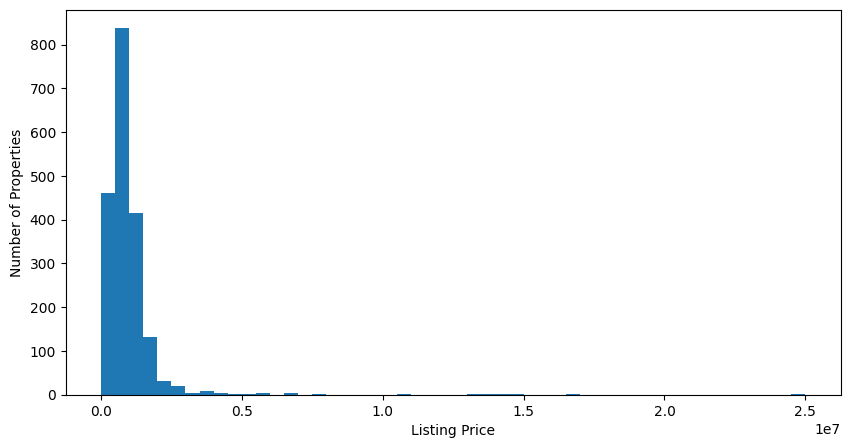

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(df['listing_price'], bins=50)
plt.xlabel("Listing Price")
plt.ylabel("Number of Properties")
plt.show()

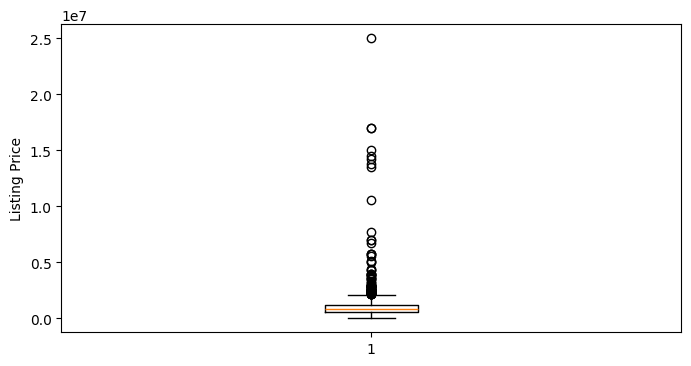

In [38]:
plt.figure(figsize=(8,4))

plt.boxplot(df['listing_price'])

plt.ylabel("Listing Price")

plt.show()

### Identifying Outliers in `listing_price` using IQR Method

Outliers are often defined as data points that fall below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`, where:

*   **Q1** is the first quartile (25th percentile).
*   **Q3** is the third quartile (75th percentile).
*   **IQR** is the Interquartile Range (`Q3 - Q1`).

In [39]:
Q1 = df['listing_price'].quantile(0.25)
Q3 = df['listing_price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['listing_price'] < lower_bound) | (df['listing_price'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1:,.2f}")
print(f"Q3 (75th percentile): {Q3:,.2f}")
print(f"IQR: {IQR:,.2f}")
print(f"Lower Bound for Outliers: {lower_bound:,.2f}")
print(f"Upper Bound for Outliers: {upper_bound:,.2f}")
print(f"\nNumber of outliers identified: {len(outliers)}")

display(outliers.head())

Q1 (25th percentile): 545,000.00
Q3 (75th percentile): 1,180,000.00
IQR: 635,000.00
Lower Bound for Outliers: -407,500.00
Upper Bound for Outliers: 2,132,500.00

Number of outliers identified: 85


,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,home_type,days_on_zillow,listing_status,zpid,tax_assessed_value,clean_address,property_key,zestimate_missing,tax_assessed_missing
9,"2117 E 73rd St, Brooklyn, NY 11234",11234,4.0,5.0,3900.0,40.620550,-73.905400,3499999.0,2705.0,3424700.0,MULTI_FAMILY,18,forSale,30782661,1361000.0,2117 E 73RD ST BROOKLYN NY 11234,30782661,0,0
11,"220 77th St, Brooklyn, NY 11209",11209,6.0,8.0,14000.0,40.630257,-74.030360,25000000.0,7538.0,856400.0,SINGLE_FAMILY,368,forSale,30696332,4460000.0,220 77TH ST BROOKLYN NY 11209,30696332,1,0
15,"215 Exeter St, Brooklyn, NY 11235",11235,7.0,8.0,11314.0,40.576916,-73.947860,13500000.0,5298.0,12693500.0,SINGLE_FAMILY,26,forSale,120730031,7168000.0,215 EXETER ST BROOKLYN NY 11235,120730031,0,0
27,"1137 Park Pl, Brooklyn, NY 11213",11213,6.0,5.0,3288.0,40.673122,-73.939840,2895000.0,5503.0,856400.0,MULTI_FAMILY,6,forSale,30592059,2434000.0,1137 PARK PL BROOKLYN NY 11213,30592059,1,0
36,"1030 73rd St, Brooklyn, NY 11228",11228,5.0,3.0,3125.0,40.624805,-74.012215,2188888.0,3493.0,2120800.0,MULTI_FAMILY,4,forSale,30694725,1563000.0,1030 73RD ST BROOKLYN NY 11228,30694725,0,0


In [40]:
df['price_per_sqft'] = (
    df['listing_price'] /
    df['living_area']
)

In [41]:
Q1 = df['listing_price'].quantile(0.25)
Q3 = df['listing_price'].quantile(0.75)

IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR

df['price_outlier'] = (
    df['listing_price'] > upper_bound
).astype(int)



In [42]:
df[df['price_outlier']==1][
    ['address','listing_price','living_area','price_per_sqft']
]


,address,listing_price,living_area,price_per_sqft
9,"2117 E 73rd St, Brooklyn, NY 11234",3499999.0,3900.0,897.435641
11,"220 77th St, Brooklyn, NY 11209",25000000.0,14000.0,1785.714286
15,"215 Exeter St, Brooklyn, NY 11235",13500000.0,11314.0,1193.211950
27,"1137 Park Pl, Brooklyn, NY 11213",2895000.0,3288.0,880.474453
36,"1030 73rd St, Brooklyn, NY 11228",2188888.0,3125.0,700.444160
...,...,...,...,...
1867,"2144 45th Rd, Long Island City, NY 11101",3750000.0,6000.0,625.000000
1870,"2113 45th Ave, Long Island City, NY 11101",4000000.0,4000.0,1000.000000
1875,"5-12 51st Ave #1, Long Island City, NY 11101",2195000.0,2110.0,1040.284360
1890,"4630 Center Blvd APT 211, Long Island City, NY...",2398000.0,1628.0,1472.972973


In [43]:
df['price_outlier'].value_counts()

,count
price_outlier,
0,1848
1,85


Meaning:

0 → normal properties
1 → luxury/high-value properties

In [44]:
df['price_vs_zestimate'] = (
    df['listing_price'] -
    df['zestimate']
)

In [45]:
df['price_zestimate_ratio'] = (
    df['listing_price'] /
    df['zestimate']
)

In [46]:
df.head(1)

,address,zip_code,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,...,zpid,tax_assessed_value,clean_address,property_key,zestimate_missing,tax_assessed_missing,price_per_sqft,price_outlier,price_vs_zestimate,price_zestimate_ratio
0,"572 Louisiana Avenue #1, Brooklyn, NY 11239",11239,2.0,2.0,1017.0,40.64762,-73.88681,250000.0,3550.0,856400.0,...,30775866,570294.0,572 LOUISIANA AVENUE BROOKLYN NY 11239,30775866,1,0,245.821042,0,-606400.0,0.29192


In [47]:
df.describe()

,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,days_on_zillow,zpid,tax_assessed_value,zestimate_missing,tax_assessed_missing,price_per_sqft,price_outlier,price_vs_zestimate,price_zestimate_ratio
count,1933.000000,1933.000000,1933.000000,1933.000000,1933.000000,1.933000e+03,1933.000000,1.933000e+03,1933.000000,1.933000e+03,1.933000e+03,1933.000000,1933.000000,1933.000000,1933.000000,1.933000e+03,1933.000000
mean,3.587170,2.535954,1749.551992,40.656078,-73.863348,1.012990e+06,3708.478013,9.513972e+05,100.531298,3.152280e+08,3.265015e+06,0.477496,0.354371,inf,0.043973,6.159233e+04,1.060570
std,2.306997,1.808187,1338.720138,0.058682,0.080771,1.238075e+06,1040.399593,8.097408e+05,140.172648,5.585006e+08,2.690910e+07,0.499623,0.478446,NaN,0.205088,8.837972e+05,1.000082
min,0.000000,0.000000,0.000000,40.556900,-74.035660,3.600000e+03,1280.000000,1.401000e+05,0.000000,3.056620e+07,2.200000e+03,0.000000,0.000000,2.907916,0.000000,-1.076900e+06,0.004204
25%,2.000000,2.000000,1050.000000,40.609140,-73.925934,5.450000e+05,3335.000000,8.446000e+05,18.000000,3.078697e+07,7.400000e+05,0.000000,0.000000,405.405405,0.000000,-5.640100e+04,0.934143
50%,3.000000,2.000000,1467.000000,40.645145,-73.893970,8.490000e+05,3550.000000,8.564000e+05,59.000000,3.222220e+07,8.170000e+05,0.000000,0.000000,523.809524,0.000000,9.200000e+03,1.013158
75%,5.000000,3.000000,2080.000000,40.681890,-73.796590,1.180000e+06,3785.000000,8.712000e+05,123.000000,4.545175e+08,9.080000e+05,1.000000,1.000000,682.051282,0.000000,5.990000e+04,1.048298
max,48.000000,48.000000,25000.000000,40.799720,-73.700676,2.500000e+07,23710.000000,1.765220e+07,1997.000000,2.146840e+09,4.007820e+08,1.000000,1.000000,inf,1.000000,2.414360e+07,29.191966


**check some issue**

1.   price_per_sqft has inf (infinity)
2.   Bedrooms = 48
3.   Bathrooms = 48
4.   Living area = 25,000 sqft
5.   days_on_zillow
6.   tax_assessed_value
7.   price_zestimate_ratio




In [48]:
# Remove invalid living area
df = df[df['living_area'] > 0]

# Recalculate price_per_sqft if you need it for analysis
df['price_per_sqft'] = df['listing_price'] / df['living_area']

# Replace any remaining infinities
df.replace([np.inf, -np.inf], np.nan, inplace=True)

/tmp/ipykernel_457/2484559735.py:8: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace([np.inf, -np.inf], np.nan, inplace=True)


In [49]:
df[df['bedrooms'] > 15][
    ['home_type', 'bedrooms', 'bathrooms', 'listing_price']
]

,home_type,bedrooms,bathrooms,listing_price
19,MULTI_FAMILY,16.0,8.0,500000.0
87,SINGLE_FAMILY,16.0,8.0,500000.0
656,SINGLE_FAMILY,20.0,16.0,2350000.0
1472,SINGLE_FAMILY,48.0,48.0,7750000.0
1811,MULTI_FAMILY,18.0,15.0,3950000.0
1813,MULTI_FAMILY,18.0,15.0,3950000.0


In [55]:
df.describe()

,bedrooms,bathrooms,living_area,latitude,longitude,listing_price,rent_estimate,zestimate,days_on_zillow,zpid,tax_assessed_value,property_key,zestimate_missing,tax_assessed_missing,price_per_sqft,price_outlier,price_vs_zestimate,price_zestimate_ratio
count,1892.000000,1892.000000,1892.000000,1892.000000,1892.000000,1.892000e+03,1892.000000,1.892000e+03,1892.000000,1.892000e+03,1.892000e+03,1.892000e+03,1892.000000,1892.000000,1892.000000,1892.000000,1.892000e+03,1892.000000
mean,3.606237,2.552854,1787.465116,40.655924,-73.864046,1.023330e+06,3710.496300,9.548356e+05,100.657505,3.137953e+08,3.286506e+06,3.137953e+08,0.475159,0.351480,631.877910,0.044926,6.849393e+04,1.068386
std,2.302787,1.813883,1327.864684,0.058830,0.080838,1.248418e+06,1047.153296,8.174521e+05,141.220584,5.578480e+08,2.718754e+07,5.578480e+08,0.499515,0.477559,1719.581332,0.207196,8.909470e+05,1.008093
min,0.000000,0.000000,20.000000,40.556900,-74.035660,3.600000e+03,1280.000000,1.401000e+05,0.000000,3.056620e+07,2.200000e+03,3.056620e+07,0.000000,0.000000,2.907916,0.000000,-1.076900e+06,0.004204
25%,2.000000,2.000000,1077.750000,40.608998,-73.926327,5.500000e+05,3329.750000,8.459750e+05,18.000000,3.078682e+07,7.400000e+05,3.078682e+07,0.000000,0.000000,401.566464,0.000000,-4.050000e+04,0.958233
50%,3.000000,2.000000,1467.000000,40.644665,-73.894705,8.500000e+05,3550.000000,8.564000e+05,59.000000,3.222177e+07,8.170000e+05,3.222177e+07,0.000000,0.000000,519.419306,0.000000,9.500000e+03,1.013414
75%,5.000000,3.000000,2100.000000,40.682123,-73.796970,1.191250e+06,3775.250000,8.767250e+05,123.000000,4.545134e+08,9.092500e+05,4.545134e+08,1.000000,1.000000,674.421371,0.000000,6.210000e+04,1.049423
max,48.000000,48.000000,25000.000000,40.799720,-73.700676,2.500000e+07,23710.000000,1.765220e+07,1997.000000,2.146840e+09,4.007820e+08,2.146840e+09,1.000000,1.000000,59523.809524,1.000000,2.414360e+07,29.191966


In [53]:
df.to_csv('final2_df.csv', index=False)

# Conclusion

The previous data-cleaning stage successfully prepared the Zillow dataset for the final cleaning process. The main data types were standardized, important numerical fields were converted into appropriate formats, and address-related information was cleaned for consistency.

At this stage, the dataset is substantially cleaner, but a few issues still need to be addressed before it can be considered fully model-ready. These include invalid property values, incorrect `home_type` classifications, and missing values in important property and financial attributes.

The next phase, **Phase 3 — Final Data Cleaning**, will focus on resolving these remaining issues through validation, rule-based corrections, and appropriate missing-value treatment.

The final objective is to produce:

```text
final_cleaned_zillow.csv
```

This dataset will then be ready for **feature engineering, exploratory data analysis, and machine-learning model development**.
